# Quickstart

This quickstart notebook is intended as a first entrypoint to working with PyVRP.
We will model and solve several vehicle routing problems, using PyVRP's high level `Model` interface.
This interface makes it easy to define routing problems directly, using familiar routing terminology of locations, clients, depots, vehicle types, and edges.

We start by modelling the routing problem of a small delivery company with a single depot and a few clients.
As the business grows and constraints become more realistic, we adapt our model step-by-step.
After the quickstart, you will be able to solve routing problems using PyVRP and are ready for the more focused tutorials presented elsewhere in our documentation.

.. note::
   The problem scale of this notebook is intentionally kept small.
   In practice, PyVRP can solve routing problems with thousands of clients, often in just a few minutes.

## Starting small

Our delivery company starts simple: initially it just wants to deliver a number of boxes to each client to meet the client demand.
The boxes are stored at the company's depot.
It has two vehicles available to deliver the boxes with, and each vehicle can carry twenty boxes.

In [1]:
import pyvrp
import pyvrp.plotting
import pyvrp.stop

In [2]:
DEPOT_COORDINATES = (51.0, 51.0)
COORDINATES = [(39, 76.5), (64.2, 47), (73, 61), (32, 38.8)]
DEMANDS = [5, 3, 7, 2]

.. caution::
   PyVRP automatically converts all numeric input values to integers, except for (x, y) coordinates.
   If your data has decimal values, you must scale and convert them to integers first to avoid unexpected behaviour.

We can specify and solve a simple model as follows using the `COORDINATES` and `DEMANDS` above.
We will use simplified Manhattan distances for the examples.
Normally, distances (and durations) need to be obtained using real-world map data, but that is outside the scope of this example.

In [3]:
m = pyvrp.Model()

depot = m.add_depot(
    location=m.add_location(DEPOT_COORDINATES[0], DEPOT_COORDINATES[1]),
    name="Depot",
)

vehicles = m.add_vehicle_type(num_available=2, capacity=20)

for idx in range(len(COORDINATES)):
    m.add_client(
        location=m.add_location(COORDINATES[idx][0], COORDINATES[idx][1]),
        delivery=DEMANDS[idx],
        name=f"Client {idx + 1}",
    )

for frm in m.locations:
    for to in m.locations:
        dist = int(abs(frm.x - to.x) + abs(frm.y - to.y))
        m.add_edge(frm, to, distance=dist)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second of runtime

PyVRP v0.14.0


Solving an instance with:


    1 depot


    4 clients


    0 shipments


...

   objective: 163


    distance: 163


    duration: 0


# iterations: 53774


    run-time: 1.00 seconds


We have quickly obtained a solution to this small problem.
PyVRP recommends using a single vehicle:

In [4]:
for idx, route in enumerate(res.best.routes()):
    print(f"Route #{idx}:")

    for activity in route:
        if activity.is_depot():
            where = m.depots[activity.idx]
        else:
            where = m.clients[activity.idx]

        print(f" - At {where}.")

Route #0:
 - At Depot.
 - At Client 4.
 - At Client 1.
 - At Client 3.
 - At Client 2.
 - At Depot.


PyVRP provides much more information about routes, schedules, and visits.
We will investigate that later, once we take into account travel duration and associated constraints.
For now, let's first explore what these routes look like visually: 

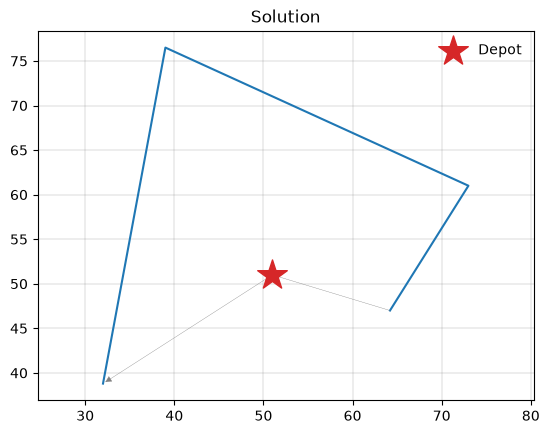

In [5]:
pyvrp.plotting.plot_solution(res.best, m.data())

We have succesfully solved our first, simple routing problem: the delivery company now knows what to do.

## Improving client and driver satisfaction

Some time later, the company again approaches us.
To improve client satisfaction, the business has agreed to deliver during specific *time windows*.
Further, the drivers were unhappy with long shifts, and demand that they only work a maximum shift duration.

To adhere to these new business constraints, we need to update our simple model to include `TIME_WINDOWS` and a `SHIFT_DURATION`.

In [6]:
TIME_WINDOWS = [(0, 60), (60, 120), (0, 60), (60, 120)]
SHIFT_DURATION = 120

We need to update our model to account for the time windows and vehicle shift duration.
That suffices to model the new business constraints.

In [7]:
m = pyvrp.Model()

depot = m.add_depot(
    location=m.add_location(DEPOT_COORDINATES[0], DEPOT_COORDINATES[1]),
    name="Depot",
)

vehicles = m.add_vehicle_type(
    num_available=2,
    capacity=20,
    shift_duration=SHIFT_DURATION,
)

for idx in range(len(COORDINATES)):
    m.add_client(
        location=m.add_location(COORDINATES[idx][0], COORDINATES[idx][1]),
        delivery=DEMANDS[idx],
        tw_early=TIME_WINDOWS[idx][0],
        tw_late=TIME_WINDOWS[idx][1],
        name=f"Client {idx + 1}",
    )

for frm in m.locations:
    for to in m.locations:
        dist = int(abs(frm.x - to.x) + abs(frm.y - to.y))
        m.add_edge(frm, to, distance=dist, duration=dist)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second of runtime

PyVRP v0.14.0


Solving an instance with:


    1 depot


    4 clients


    0 shipments


...

   objective: 183


    distance: 183


    duration: 183


# iterations: 49223


    run-time: 1.00 seconds


PyVRP found a new solution, this time using both vehicles to spread the work.
Let's investigate the route plan:

In [8]:
for idx, route in enumerate(res.best.routes()):
    print(f"Route #{idx} [duration = {route.duration()}]:")

    for activity in route:
        if activity.is_depot():
            where = m.depots[activity.idx]
        else:
            where = m.clients[activity.idx]

        print(f" - [t = {activity.start_time:>03}] At {where}.")

Route #0 [duration = 71]:
 - [t = 006] At Depot.
 - [t = 038] At Client 3.
 - [t = 060] At Client 2.
 - [t = 077] At Depot.
Route #1 [duration = 112]:
 - [t = 000] At Depot.
 - [t = 037] At Client 1.
 - [t = 081] At Client 4.
 - [t = 112] At Depot.


These routes respect the client time windows, as well as the driver's shift durations.

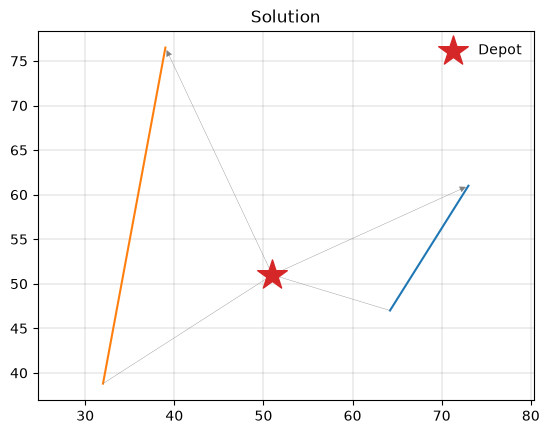

In [9]:
pyvrp.plotting.plot_solution(res.best, m.data())

PyVRP supports many more time and duration constraints beyond time windows and shift durations.
These include latest start constraints and overtime costs for vehicles, release times for client deliveries, service durations at clients and depots, and time windows for depots.

## A business expansion

Both clients and drivers are happy with the routing decisions made using our updated model.
Business is doing well, and a second depot was recently opened to meet additional demand from new clients.
The new depot initially has a single vehicle available.
The company again approaches us, to help answer which clients should be serviced from each depot.

Luckily, PyVRP can easily solve routing problems with multiple depots.
We simply extend the previous model with new data:

In [10]:
NEW_COORDINATES = [(30, 80), (50, 90), (38.5, 82)]
NEW_DEMANDS = [5, 3, 7]
NEW_TIME_WINDOWS = [(0, 80), (0, 80), (80, 120)]

In [11]:
# We extend the previous model with the new data.
new_depot = m.add_depot(
    location=m.add_location(x=40.0, y=70.0),
    name="New depot",
)

new_vehicles = m.add_vehicle_type(
    num_available=1,
    capacity=20,
    start_depot=new_depot,
    end_depot=new_depot,
    shift_duration=SHIFT_DURATION,
)

for idx in range(len(NEW_COORDINATES)):
    loc = m.add_location(NEW_COORDINATES[idx][0], NEW_COORDINATES[idx][1])
    m.add_client(
        location=loc,
        delivery=NEW_DEMANDS[idx],
        tw_early=NEW_TIME_WINDOWS[idx][0],
        tw_late=NEW_TIME_WINDOWS[idx][1],
        name=f"New client {idx + 1}",
    )

for frm in m.locations:
    for to in m.locations:
        dist = int(abs(frm.x - to.x) + abs(frm.y - to.y))
        m.add_edge(frm, to, distance=dist, duration=dist)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second of runtime

PyVRP v0.14.0


Solving an instance with:


    2 depots


    7 clients


    0 shipments


...

   objective: 214


    distance: 214


    duration: 214


# iterations: 27370


    run-time: 1.00 seconds


PyVRP found a solution using three vehicles:

In [12]:
for idx, route in enumerate(res.best.routes()):
    print(f"Route #{idx} [duration = {route.duration()}]:")

    for activity in route:
        if activity.is_depot():
            where = m.depots[activity.idx]
        else:
            where = m.clients[activity.idx]

        print(f" - [t = {activity.start_time:>03}] At {where}.")

Route #0 [duration = 62]:
 - [t = 029] At Depot.
 - [t = 060] At Client 4.
 - [t = 091] At Depot.
Route #1 [duration = 71]:
 - [t = 006] At Depot.
 - [t = 038] At Client 3.
 - [t = 060] At Client 2.
 - [t = 077] At Depot.
Route #2 [duration = 81]:
 - [t = 012] At New depot.
 - [t = 019] At Client 1.
 - [t = 031] At New client 1.
 - [t = 061] At New client 2.
 - [t = 080] At New client 3.
 - [t = 093] At New depot.


Let's have a look:

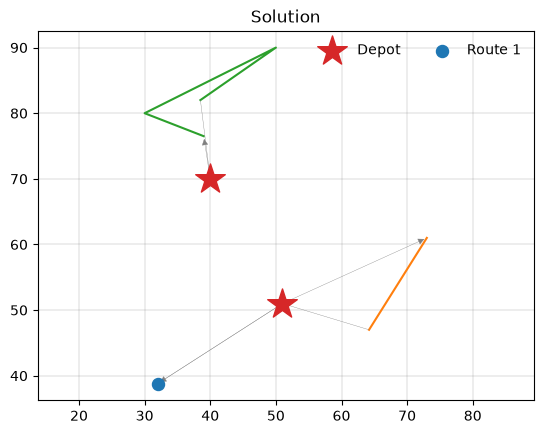

In [13]:
pyvrp.plotting.plot_solution(res.best, m.data())

Additionally, PyVRP supports vehicles starting and ending their routes at different depots, as well as reloading along the route.

## Conclusion

In this quickstart notebook we have solved the business case of a small delivery company.
You have learned how to specify depots, vehicle types, and clients using PyVRP's modelling interface, and learned how to model time and duration constraints, as well as multiple depots.
With these fundamentals, you now have a solid grasp of modelling routing problems with PyVRP.

.. hint::
   Along the way, we have hinted at various additional constraints and features that PyVRP supports.
   These features are treated in more detail in the tutorials.

.. hint::
   The [API reference](https://pyvrp.org/api/pyvrp.html) contains a complete reference of our implementation.